# Classification — Non-Temporal Approach

This notebook builds and evaluates a non-temporal classification pipeline for **next-day mood prediction**.
The engineered feature datasets are produced by `1c_feature_engineering_non_temporal/feature_engineering.ipynb`
for each candidate window size.

## Pipeline overview
1. Load train / val / test splits for **all window sizes**
2. Define the 3-class target (tertile thresholds from each window's train split)
3. Preprocessing: median imputation per window size
4. **Cross-window training** — for each window size, train and tune all models on train, score on val
5. **Model selection** — pick best (window size, model, hyperparameters) by val macro F1
6. **Final test** — retrain best model on train + val; evaluate once on held-out test set
7. Report: confusion matrix, per-class metrics, feature importances

In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

DATA_DIR = Path("../1c_feature_engineering_non_temporal/output")
WINDOW_SIZES = [1, 3, 5, 7, 14]
META_COLS = ["id", "target_date", "target_mood"]
CLASS_NAMES = ["Low", "Medium", "High"]

---
## 1. Load data for all window sizes

In [3]:
data = {}  # ws -> {"train": df, "val": df, "test": df}

for ws in WINDOW_SIZES:
    try:
        train_raw = pd.read_parquet(DATA_DIR / f"train_w{ws}.parquet")
        val_raw = pd.read_parquet(DATA_DIR / f"val_w{ws}.parquet")
        test_raw = pd.read_parquet(DATA_DIR / f"test_w{ws}.parquet")
        data[ws] = {"train": train_raw, "val": val_raw, "test": test_raw}
        feat_cols = [c for c in train_raw.columns if c not in META_COLS]
        print(
            f"w={ws:>2}d  train={len(train_raw):>4}  val={len(val_raw):>4}"
            f"  test={len(test_raw):>4}  features={len(feat_cols)}"
        )
    except FileNotFoundError:
        print(f"w={ws:>2}d  NOT FOUND — run feature_engineering.ipynb first")

print(f"\nLoaded window sizes: {sorted(data.keys())}")

w= 1d  train= 858  val= 136  test= 265  features=130
w= 3d  train= 864  val= 136  test= 268  features=132
w= 5d  train= 864  val= 136  test= 268  features=134
w= 7d  train= 864  val= 136  test= 268  features=136
w=14d  train= 864  val= 136  test= 268  features=143

Loaded window sizes: [1, 3, 5, 7, 14]


---
## 2. Classification target: 3-class mood (per window size)

The raw target `target_mood` is discretised into three ordered classes using **tertile
thresholds computed from each window's training set only** (no leakage into val/test).

| Class | Label | Condition |
|---|---|---|
| 0 | **Low** | mood ≤ train 33rd percentile |
| 1 | **Medium** | train 33rd < mood ≤ train 67th percentile |
| 2 | **High** | mood > train 67th percentile |

In [4]:
def mood_to_class(series: pd.Series, q33: float, q67: float) -> np.ndarray:
    return (
        pd.cut(series, bins=[-np.inf, q33, q67, np.inf], labels=[0, 1, 2])
        .astype(int)
        .values
    )


targets = {}  # ws -> {Q33, Q67, y_train, y_val, y_test}

for ws, splits in data.items():
    Q33 = splits["train"]["target_mood"].quantile(1 / 3)
    Q67 = splits["train"]["target_mood"].quantile(2 / 3)
    y_train = mood_to_class(splits["train"]["target_mood"], Q33, Q67)
    y_val = mood_to_class(splits["val"]["target_mood"], Q33, Q67)
    y_test = mood_to_class(splits["test"]["target_mood"], Q33, Q67)
    targets[ws] = {
        "Q33": Q33,
        "Q67": Q67,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
    }
    vals, cnts = np.unique(y_train, return_counts=True)
    dist = {CLASS_NAMES[v]: c for v, c in zip(vals, cnts)}
    print(f"w={ws:>2}d  thresholds: low<{Q33:.3f}  med<{Q67:.3f}  train dist={dist}")

w= 1d  thresholds: low<6.667  med<7.200  train dist={'Low': np.int64(289), 'Medium': np.int64(309), 'High': np.int64(260)}
w= 3d  thresholds: low<6.667  med<7.200  train dist={'Low': np.int64(291), 'Medium': np.int64(312), 'High': np.int64(261)}
w= 5d  thresholds: low<6.667  med<7.200  train dist={'Low': np.int64(291), 'Medium': np.int64(312), 'High': np.int64(261)}
w= 7d  thresholds: low<6.667  med<7.200  train dist={'Low': np.int64(291), 'Medium': np.int64(312), 'High': np.int64(261)}
w=14d  thresholds: low<6.667  med<7.200  train dist={'Low': np.int64(291), 'Medium': np.int64(312), 'High': np.int64(261)}


---
## 3. Preprocessing

**Imputation:** ~7% of feature values are missing (mostly lag features and same-weekday lags
early in a patient's observation period, and sparse app-category features).
We use **median imputation** fit on the training set only.

The missingness itself is already captured by dedicated `_n_missing_days` and `_obs_frac`
features in the dataset, so imputing the value does not hide the absence signal.

**Scaling:** applied in the Logistic Regression pipeline only.
Tree models (RF, HistGB) are scale-invariant.

In [5]:
preprocessed = {}  # ws -> dict of arrays + PredefinedSplit

for ws, splits in data.items():
    feat_cols = [c for c in splits["train"].columns if c not in META_COLS]

    X_train_raw = splits["train"][feat_cols].values
    X_val_raw = splits["val"][feat_cols].values
    X_test_raw = splits["test"][feat_cols].values

    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train_raw)
    X_val = imputer.transform(X_val_raw)
    X_test = imputer.transform(X_test_raw)

    y_train = targets[ws]["y_train"]
    y_val = targets[ws]["y_val"]

    X_trainval = np.vstack([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])
    split_idx = [-1] * len(X_train) + [0] * len(X_val)

    preprocessed[ws] = {
        "feat_cols": feat_cols,
        "imputer": imputer,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "X_train_raw": X_train_raw,
        "X_val_raw": X_val_raw,
        "X_test_raw": X_test_raw,
        "X_trainval": X_trainval,
        "y_trainval": y_trainval,
        "pre_split": PredefinedSplit(test_fold=split_idx),
    }

print("Preprocessing complete for all window sizes.")
print(f"Post-imputation NaN check (w=7): {np.isnan(preprocessed[7]['X_train']).sum()}")

Preprocessing complete for all window sizes.
Post-imputation NaN check (w=7): 0


---
## 4. Evaluation setup

### Why we do NOT use random cross-validation

The dataset contains **repeated observations from 27 patients**. Random k-fold would mix
past and future observations from the same patient across folds, causing temporal leakage.

### Our approach

We use the **pre-existing time-wise per-patient splits** from the feature engineering step.
For each window size, `PredefinedSplit` trains on the train fold and scores on val during
hyperparameter search. The **primary metric is macro F1** (treats all three mood classes equally).

### Selection process
1. For each window size: train Dummy, Logistic Regression, tuned Random Forest, tuned HistGradientBoosting
2. Compare all (window size, model) combos by val macro F1 → select the winner
3. Retrain the winner on train + val → evaluate **once** on the held-out test set

In [6]:
# Hyperparameter search spaces (shared across all window sizes)
RF_PARAM_DIST = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "class_weight": ["balanced", None],
}

HGB_PARAM_DIST = {
    "max_iter": [100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "min_samples_leaf": [10, 20, 30],
    "l2_regularization": [0.0, 0.1, 1.0],
    "class_weight": ["balanced", None],
}

print("Hyperparameter search spaces defined.")

Hyperparameter search spaces defined.


---
## 5. Cross-window model training

For each window size we train four model types:

| Model | Notes |
|---|---|
| **Dummy** | Always predicts majority class — establishes the floor |
| **Logistic Regression** | Linear baseline; L2 regularisation, balanced class weights |
| **Random Forest** | 80-iteration randomised search with `PredefinedSplit` |
| **Hist. Gradient Boosting** | 80-iteration randomised search; handles NaN natively |

All hyperparameter searches use `PredefinedSplit` (train fold → fitting, val fold → scoring)
so the val set is never used for anything other than model selection.

In [7]:
all_val_results = []  # list of dicts: window_size, model, acc, macro_f1, weighted_f1
fitted_models = {}  # (ws, model_name) -> fitted model (trained on train only)
best_rf_params = {}  # ws -> best RF params from search
best_hgb_params = {}  # ws -> best HGB params from search

for ws in sorted(preprocessed.keys()):
    pp = preprocessed[ws]
    y_train = targets[ws]["y_train"]
    y_val = targets[ws]["y_val"]

    print(f"\n{'=' * 65}")
    print(f" Window = {ws} days  |  train={len(y_train)}  val={len(y_val)}")
    print(f"{'=' * 65}")

    def _record(model_name, y_pred):
        r = {
            "window_size": ws,
            "model": model_name,
            "acc": round(accuracy_score(y_val, y_pred), 4),
            "macro_f1": round(f1_score(y_val, y_pred, average="macro"), 4),
            "weighted_f1": round(f1_score(y_val, y_pred, average="weighted"), 4),
        }
        all_val_results.append(r)
        print(f"  {model_name:50s}  macro-F1={r['macro_f1']:.4f}")

    # ── Dummy ────────────────────────────────────────────────────────────────
    dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
    dummy.fit(pp["X_train"], y_train)
    _record("Dummy", dummy.predict(pp["X_val"]))
    fitted_models[(ws, "Dummy")] = dummy

    # ── Logistic Regression ──────────────────────────────────────────────────
    lr = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    C=0.1,
                ),
            ),
        ]
    )
    lr.fit(pp["X_train_raw"], y_train)
    _record("Logistic Regression", lr.predict(pp["X_val_raw"]))
    fitted_models[(ws, "Logistic Regression")] = lr

    # ── Random Forest (tuned) ────────────────────────────────────────────────
    rf_search = RandomizedSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE),
        param_distributions=RF_PARAM_DIST,
        n_iter=80,
        cv=pp["pre_split"],
        scoring="f1_macro",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=False,
        verbose=0,
    )
    rf_search.fit(pp["X_trainval"], pp["y_trainval"])
    best_rf_params[ws] = rf_search.best_params_
    rf = RandomForestClassifier(**rf_search.best_params_, random_state=RANDOM_STATE)
    rf.fit(pp["X_train"], y_train)
    _record("Random Forest (tuned)", rf.predict(pp["X_val"]))
    fitted_models[(ws, "Random Forest (tuned)")] = rf

    # ── Hist. Gradient Boosting (tuned) ──────────────────────────────────────
    hgb_search = RandomizedSearchCV(
        HistGradientBoostingClassifier(
            random_state=RANDOM_STATE, categorical_features=None
        ),
        param_distributions=HGB_PARAM_DIST,
        n_iter=80,
        cv=pp["pre_split"],
        scoring="f1_macro",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=False,
        verbose=0,
    )
    hgb_search.fit(pp["X_trainval"], pp["y_trainval"])
    best_hgb_params[ws] = hgb_search.best_params_
    hgb = HistGradientBoostingClassifier(
        **hgb_search.best_params_, random_state=RANDOM_STATE, categorical_features=None
    )
    hgb.fit(pp["X_train"], y_train)
    _record("Hist. Gradient Boosting (tuned)", hgb.predict(pp["X_val"]))
    fitted_models[(ws, "Hist. Gradient Boosting (tuned)")] = hgb

print("\nTraining complete.")


 Window = 1 days  |  train=858  val=136
  Dummy                                               macro-F1=0.1070
  Logistic Regression                                 macro-F1=0.3385
  Random Forest (tuned)                               macro-F1=0.5385
  Hist. Gradient Boosting (tuned)                     macro-F1=0.5277

 Window = 3 days  |  train=864  val=136
  Dummy                                               macro-F1=0.1070
  Logistic Regression                                 macro-F1=0.4236
  Random Forest (tuned)                               macro-F1=0.5079
  Hist. Gradient Boosting (tuned)                     macro-F1=0.4667

 Window = 5 days  |  train=864  val=136
  Dummy                                               macro-F1=0.1070
  Logistic Regression                                 macro-F1=0.2358
  Random Forest (tuned)                               macro-F1=0.5580
  Hist. Gradient Boosting (tuned)                     macro-F1=0.4864

 Window = 7 days  |  train=864  val=

---
## 6. Validation results — all window sizes × models

In [8]:
val_df = (
    pd.DataFrame(all_val_results)
    .sort_values(["macro_f1", "window_size"], ascending=[False, True])
    .reset_index(drop=True)
)
print("=== Validation results (sorted by macro F1) ===")
print(val_df.to_string(index=False))

# Best (window_size, model) combo
best_row = val_df.iloc[0]
BEST_WS = int(best_row["window_size"])
BEST_MODEL = best_row["model"]
print(
    f"\n>>> Best: window={BEST_WS}d  |  model={BEST_MODEL}  |  val macro-F1={best_row['macro_f1']:.4f}"
)

=== Validation results (sorted by macro F1) ===
 window_size                           model    acc  macro_f1  weighted_f1
           5           Random Forest (tuned) 0.6544    0.5580       0.6636
           1           Random Forest (tuned) 0.6176    0.5385       0.6458
           1 Hist. Gradient Boosting (tuned) 0.6250    0.5277       0.6389
           7           Random Forest (tuned) 0.6324    0.5201       0.6354
          14           Random Forest (tuned) 0.5882    0.5089       0.6135
           3           Random Forest (tuned) 0.6103    0.5079       0.6242
           5 Hist. Gradient Boosting (tuned) 0.6103    0.4864       0.6232
          14 Hist. Gradient Boosting (tuned) 0.6324    0.4826       0.6341
           3 Hist. Gradient Boosting (tuned) 0.5956    0.4667       0.5992
           3             Logistic Regression 0.4926    0.4236       0.5268
           7 Hist. Gradient Boosting (tuned) 0.4632    0.3942       0.5007
           1             Logistic Regression 0.4338 

---
## 7. Final evaluation on the test set

The best (window size, model) is retrained on **train + val combined**, then evaluated
**once** on the held-out test set. The test set has not been touched during any part of
the selection process.

In [9]:
pp = preprocessed[BEST_WS]
y_trainval = pp["y_trainval"]
y_test = targets[BEST_WS]["y_test"]

print(f"Retraining '{BEST_MODEL}' on train+val (window={BEST_WS}d)...")

if BEST_MODEL == "Logistic Regression":
    # LR pipeline operates on raw (unimputed) arrays
    X_tv = np.vstack([pp["X_train_raw"], pp["X_val_raw"]])
    final_model = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    C=0.1,
                ),
            ),
        ]
    )
    final_model.fit(X_tv, y_trainval)
    y_test_pred = final_model.predict(pp["X_test_raw"])

elif BEST_MODEL == "Dummy":
    final_model = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
    final_model.fit(pp["X_trainval"], y_trainval)
    y_test_pred = final_model.predict(pp["X_test"])

elif BEST_MODEL == "Random Forest (tuned)":
    final_model = RandomForestClassifier(
        **best_rf_params[BEST_WS], random_state=RANDOM_STATE
    )
    final_model.fit(pp["X_trainval"], y_trainval)
    y_test_pred = final_model.predict(pp["X_test"])

elif BEST_MODEL == "Hist. Gradient Boosting (tuned)":
    final_model = HistGradientBoostingClassifier(
        **best_hgb_params[BEST_WS], random_state=RANDOM_STATE, categorical_features=None
    )
    final_model.fit(pp["X_trainval"], y_trainval)
    y_test_pred = final_model.predict(pp["X_test"])

print(f"\n{'=' * 60}")
print(f" {BEST_MODEL}  (window={BEST_WS}d) — TEST SET")
print(f"{'=' * 60}")
print(f"Accuracy    : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Macro F1    : {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"Weighted F1 : {f1_score(y_test, y_test_pred, average='weighted'):.4f}")
print("\nPer-class report:")
print(classification_report(y_test, y_test_pred, target_names=CLASS_NAMES))

Retraining 'Random Forest (tuned)' on train+val (window=5d)...

 Random Forest (tuned)  (window=5d) — TEST SET
Accuracy    : 0.4925
Macro F1    : 0.4986
Weighted F1 : 0.4901

Per-class report:
              precision    recall  f1-score   support

         Low       0.54      0.53      0.53        59
      Medium       0.46      0.41      0.43       111
        High       0.50      0.57      0.53        98

    accuracy                           0.49       268
   macro avg       0.50      0.50      0.50       268
weighted avg       0.49      0.49      0.49       268



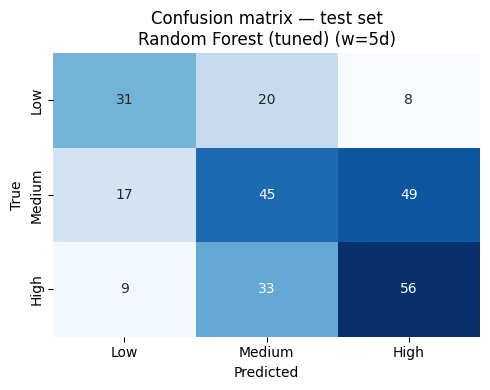

Saved: confusion_matrix.png


In [10]:
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax,
    cbar=False,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — test set\n{BEST_MODEL} (w={BEST_WS}d)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

---
## 10. Feature importances (Random Forest)

Top 20 most important features:
                    feature  importance
              mood_win_mean    0.099290
                  mood_lag1    0.065710
               mood_win_min    0.024788
              activity_lag1    0.021158
  appCat_entertainment_prop    0.020044
               mood_win_std    0.019637
                  mood_lag2    0.018047
  appCat_communication_prop    0.017667
                 mood_trend    0.017093
               mood_win_max    0.017072
        mood_same_wday_lag7    0.016963
         appCat_social_prop    0.016844
 circumplex_arousal_win_std    0.016635
circumplex_arousal_win_mean    0.014980
    activity_same_wday_lag7    0.014329
             target_dow_sin    0.014154
          activity_win_mean    0.013816
           activity_win_std    0.013583
circumplex_valence_win_mean    0.013329
        appCat_builtin_prop    0.013097


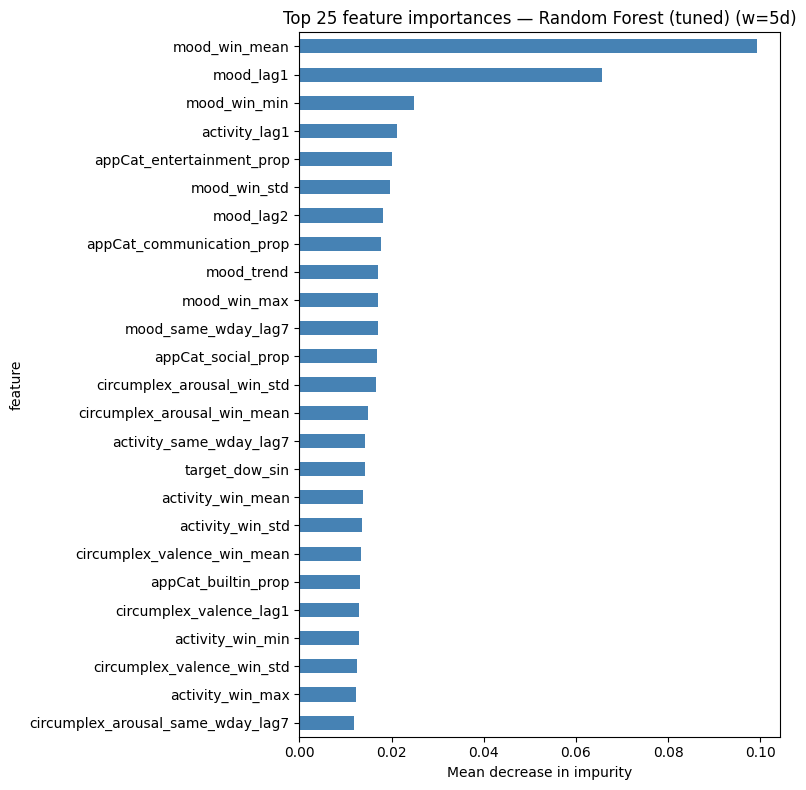

Saved: feature_importances.png


In [11]:
if not hasattr(final_model, "feature_importances_"):
    print(f"Feature importances not available for {BEST_MODEL}.")
else:
    feat_cols = preprocessed[BEST_WS]["feat_cols"]
    feat_imp_df = (
        pd.DataFrame(
            {"feature": feat_cols, "importance": final_model.feature_importances_}
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    print("Top 20 most important features:")
    print(feat_imp_df.head(20).to_string(index=False))

    top_n = 25
    fig, ax = plt.subplots(figsize=(8, 8))
    feat_imp_df.head(top_n).sort_values("importance").plot(
        kind="barh", x="feature", y="importance", ax=ax, legend=False, color="steelblue"
    )
    ax.set_xlabel("Mean decrease in impurity")
    ax.set_title(f"Top {top_n} feature importances — {BEST_MODEL} (w={BEST_WS}d)")
    plt.tight_layout()
    plt.savefig("feature_importances.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: feature_importances.png")

---
## 11. Final results summary

In [12]:
# Show the full validation leaderboard pivoted by window size
pivot = val_df.pivot(index="model", columns="window_size", values="macro_f1")
print("=== Val macro-F1 by model × window size ===")
print(pivot.round(4).to_string())

print(f"\n>>> Selected: window={BEST_WS}d  |  {BEST_MODEL}")
print(f"    Val macro-F1  : {best_row['macro_f1']:.4f}")
print(f"    Test macro-F1 : {f1_score(y_test, y_test_pred, average='macro'):.4f}")

=== Val macro-F1 by model × window size ===
window_size                          1       3       5       7       14
model                                                                  
Dummy                            0.1070  0.1070  0.1070  0.1070  0.1070
Hist. Gradient Boosting (tuned)  0.5277  0.4667  0.4864  0.3942  0.4826
Logistic Regression              0.3385  0.4236  0.2358  0.2264  0.3026
Random Forest (tuned)            0.5385  0.5079  0.5580  0.5201  0.5089

>>> Selected: window=5d  |  Random Forest (tuned)
    Val macro-F1  : 0.5580
    Test macro-F1 : 0.4986


---
## 11. Discussion

### Classification target
Daily mean mood was discretised into three balanced classes (Low / Medium / High) using
tertile thresholds computed from each window's training set only, preventing data leakage.

### Selection process
All candidate (window size, model) combinations were evaluated on the validation set.
The best combination was selected by **val macro F1**, then retrained on train+val and
evaluated **once** on the test set. The test set was never involved in any selection decision.

### Feature importance interpretation
The most important features are consistently the **recent mood lags** (`mood_lag1`, `mood_lag2`,
`mood_win_mean`), confirming that next-day mood is strongly autocorrelated.
Behavioural features (screen time, social app usage) and missingness indicators contribute
additional signal beyond the mood history alone.

### Limitations
- The dataset is small (≈700 training instances, 27 patients). Performance estimates
  have wide confidence intervals.
- Patient-level effects are not modelled; a mixed-effects or patient-stratified model
  may perform better.

### Reproducibility
All random operations use `RANDOM_STATE = 42`. Preprocessing (imputer fitted on train only)
and `PredefinedSplit` hyperparameter search are fully deterministic. Run cells top-to-bottom
to reproduce all results.